In [5]:
import numpy as np
import pandas as pd

np.random.seed(123)

n_samples=1000
class_0_ratio=0.9
n_class_0=int(n_samples*class_0_ratio)
n_class_1=n_samples-n_class_0

In [6]:
n_class_0,n_class_1

(900, 100)

In [9]:
# creating dataset
class_0=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})

class_1=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_1),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_1),
    'target':[1]*n_class_1
})

In [15]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)

In [16]:
df.head()

,feature_1,feature_2,target
0,-1.774224,0.285744,0
1,-1.201377,0.333279,0
2,1.096257,0.531807,0
3,0.861037,-0.354766,0
4,-1.520367,-1.120815,0


# 1) up sampling

In [17]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [21]:
from sklearn.utils import resample
df_minority_resampled=resample(df_minority,replace=True,
        n_samples=len(df_majority),
        random_state=42)

In [23]:
df_upsampled=pd.concat([df_majority,df_minority_resampled])

In [24]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

## 2)Downsampling

In [25]:
# creating dataset
class_0=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})

class_1=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_1),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_1),
    'target':[1]*n_class_1
})

In [26]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [28]:
from sklearn.utils import resample
df_majority_downsampled=resample(df_majority,replace=False,
        n_samples=len(df_minority),
        random_state=42)

In [29]:
df_downsampled=pd.concat([df_majority_downsampled,df_minority])

In [31]:
df_downsampled['target'].value_counts()

target
0    100
1    100
Name: count, dtype: int64

# SMOTE

In [33]:
from sklearn.datasets import make_classification

In [49]:
x,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,
                   weights=[0.90],random_state=42)

In [50]:
import pandas as pd
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
fina_df=pd.concat([df1,df2],axis=1)
fina_df

,f1,f2,target
0,1.073546,-1.101339,0
1,0.755945,-1.172352,0
2,1.354479,-0.948528,0
3,3.103090,0.233485,0
4,1.951888,-0.270157,0
...,...,...,...
995,1.713939,0.451639,1
996,1.509473,-0.794996,0
997,-2.150901,-2.989372,0
998,2.451647,-0.156629,0


In [51]:
fina_df['target'].value_counts()

target
0    896
1    104
Name: count, dtype: int64

In [53]:
import matplotlib.pyplot as plt

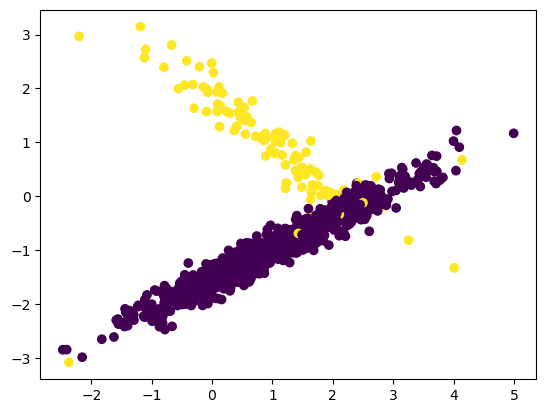

In [54]:
plt.scatter(fina_df['f1'],fina_df['f2'],c=fina_df['target'])

In [56]:
!pip install imblearn

In [58]:
from imblearn.over_sampling import SMOTE

In [61]:
#transform the dataset
oversample=SMOTE()
x,y=oversample.fit_resample(fina_df[['f1','f2']],fina_df['target'])

In [62]:
x.shape

(1792, 2)

In [63]:
len(y[y==0])

896

In [64]:
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)

In [66]:
oversample_df

,f1,f2,target
0,1.073546,-1.101339,0
1,0.755945,-1.172352,0
2,1.354479,-0.948528,0
3,3.103090,0.233485,0
4,1.951888,-0.270157,0
...,...,...,...
1787,1.627447,-0.448727,1
1788,1.116669,1.003761,1
1789,1.382230,0.353582,1
1790,0.858178,1.066880,1


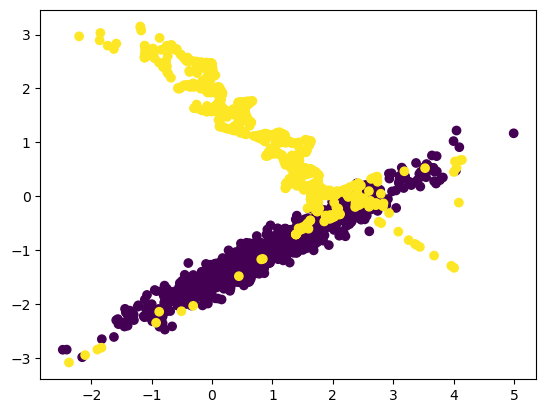

In [67]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])